# OSETI Automated Search Threshold Figure

This notebook creates "threshold.pdf".  Caption:

A comparison of thresholds used for our automated spike detection algorithm.  Solid blue: an example HARPS spectrum.  Dashed orange: spike detection threshold based on running standard deviation with a window width w=100.  This threshold rises near the spikes, so our algorithm would not detect either. Dotted green: threshold based on running 85th percentile with a window width w=100. Note the lower threshold near the spikes.  Dash-dotted red: threshold based on running 85th percentile with a window width w=1000.  This gives a low, flat threshold and thus more sensitive and robust spike detection.  Our automated search detects the spike at 3964.6 \AA.  The one on the left has too few points above the detection threshold and would not be flagged.

In [1]:
%matplotlib widget

Set up and import

In [2]:
from astroquery.eso import Eso
eso = Eso()
from pathlib import Path
eso_cache_folder = Path(eso.cache_location)
import optical_seti_functions
import harpscompare
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
mpl.rcParams['axes.titlesize'] = 'medium'
mpl.rcParams['axes.labelsize'] = 'medium'
figurewidth=8
figureheight=3.75

In [3]:
if not eso.authenticated():
    eso.login(username="goodmanj", store_password=True)

INFO: Authenticating goodmanj on 'www.eso.org' ... [astroquery.eso.core]
INFO: Authentication successful! [astroquery.eso.core]


In [4]:
specfile = "ADP.2014-09-23T11:05:18.897".replace(":","_")
dlfile = harpscompare.download_spectrum(specfile,replace_underscores=True)


INFO: Authenticating goodmanj on 'www.eso.org' ... [astroquery.eso.core]
INFO: Authentication successful! [astroquery.eso.core]
INFO: Downloading datasets ... [astroquery.eso.core]
INFO: Downloading 1 files ... [astroquery.eso.core]
INFO: Downloading file 1/1 https://dataportal.eso.org/dataPortal/file/ADP.2014-09-23T11:05:18.897 to C:\Users\goodm\.astropy\cache\astroquery\Eso [astroquery.eso.core]
INFO: Found cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-23T11_05_18.897.fits [astroquery.eso.core]
INFO: Done! [astroquery.eso.core]


In [5]:
specfits = fits.open(dlfile)
wave = specfits[1].data[0][0]
arr1 = specfits[1].data[0][1]

runmed = optical_seti_functions.running_median(arr1,window_size=101)
runstd = optical_seti_functions.running_standarddev(arr1,stwindow=101)
run85 = optical_seti_functions.running_percentile(arr1,85,stwindow=101)
runmed_1000 = optical_seti_functions.running_median(arr1,window_size=1001)
run85_1000 = optical_seti_functions.running_percentile(arr1,85,stwindow=1001)

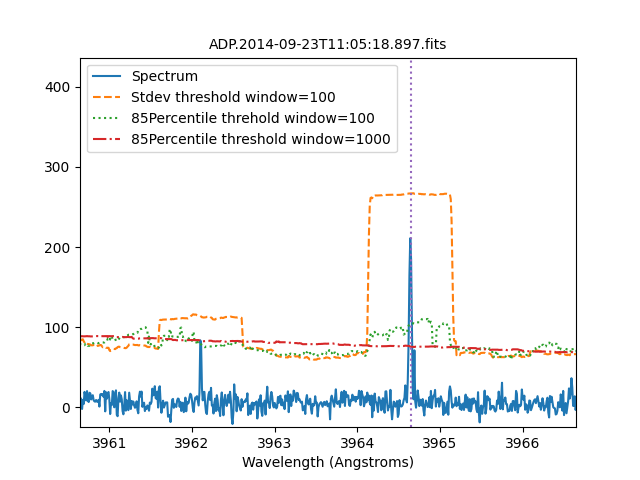

In [7]:
lamb = (3964.62+3964.67)/2
spec_countmin = np.mean(arr1)-3*np.std(arr1)  # Try to make plot axis limits reasonable based on range of data
spec_countmax = np.mean(arr1)+15*np.std(arr1)
plt.figure(1)
plt.clf()
wavecrop101 = wave[50:-50]
wavecrop1001 = wave[500:-500]
plt.plot(wave,arr1,"-",wavecrop101,runmed+7.5*runstd,"--",wavecrop101,runmed+7.5*(run85-runmed),":",wavecrop1001,runmed_1000+7.5*(run85_1000-runmed_1000),"-.")
plt.legend(["Spectrum","Stdev threshold window=100","85Percentile threhold window=100", "85Percentile threshold window=1000"])
plt.plot([lamb, lamb],[spec_countmin, spec_countmax],':')  # Plot a dotted line showing the location of our spike
plt.xlim([lamb-4,lamb+2])
plt.ylim([spec_countmin,spec_countmax]) 
plt.title(specfits[0].header['ARCFILE'])
plt.xlabel("Wavelength (Angstroms)")
plt.show()
plt.savefig("manuscript-figures/threshold.pdf",format="pdf")